Libraries imported successfully!

Dataset loaded successfully!
Rows: 32581
Columns: 12

--- First 5 Rows ---
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file 

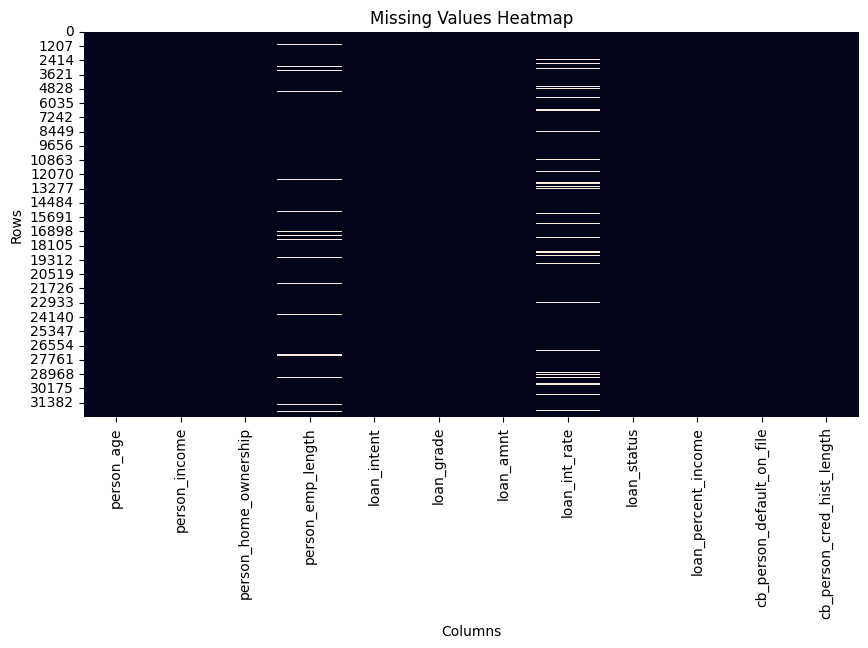

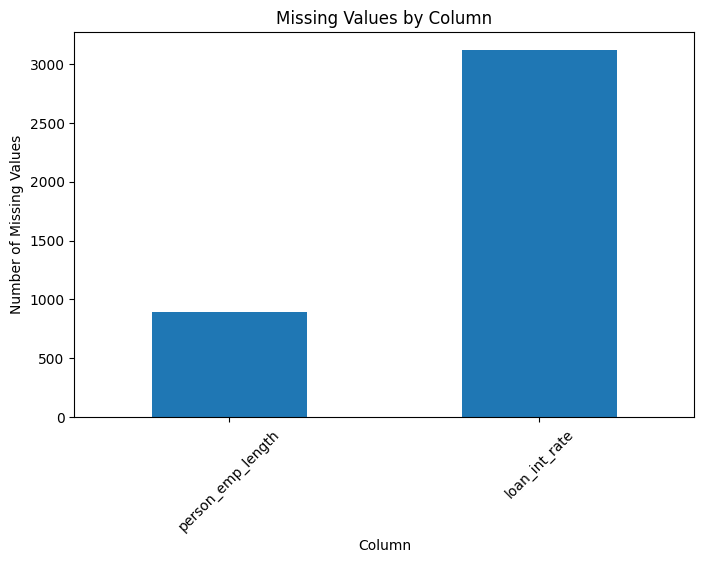


Number of duplicate rows: 165
Dataset shape after removing duplicates: (32416, 12)

Missing values status after duplicate removal:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing numerical values handled successfully.
Missing values remaining:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person

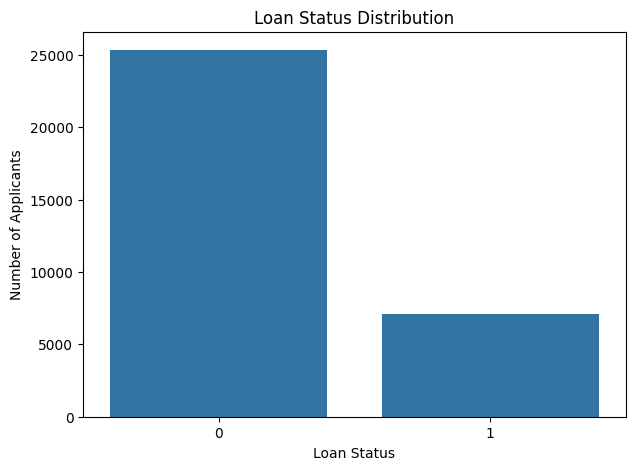


Target Class Percentages:
loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64


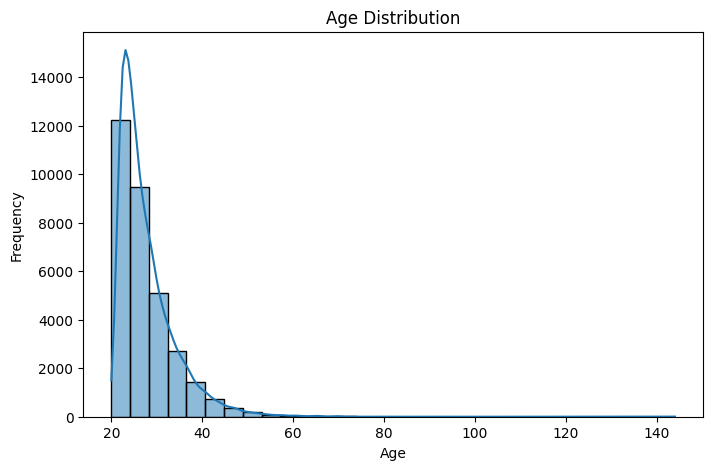

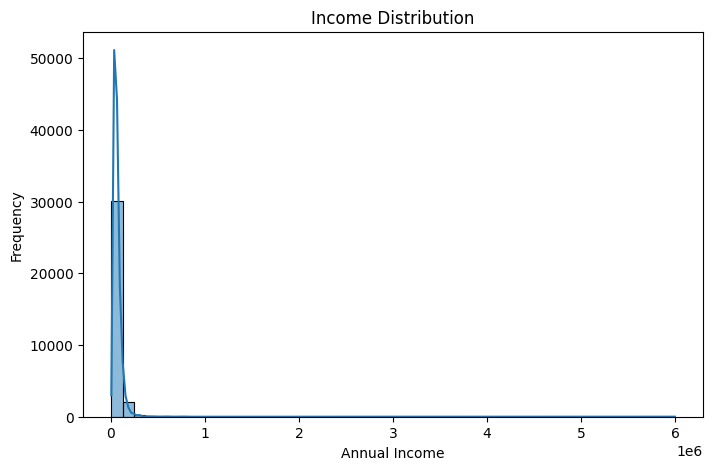

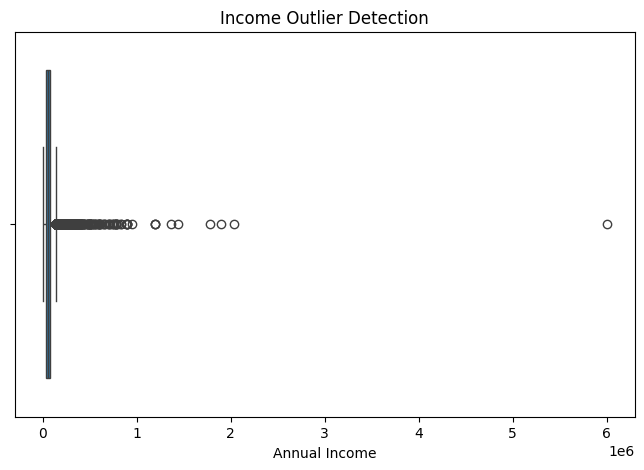

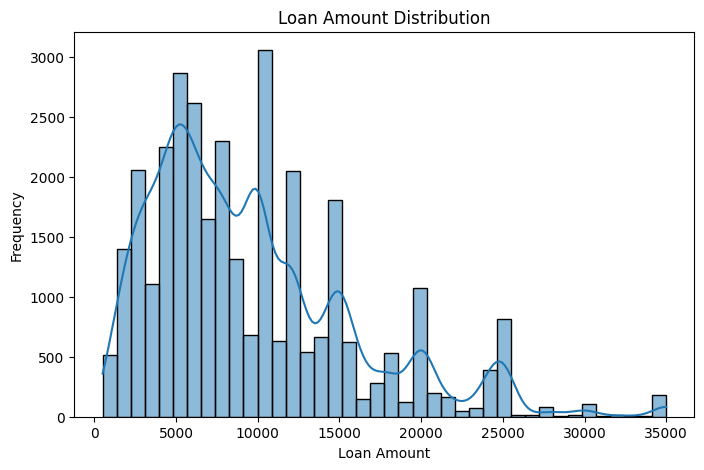

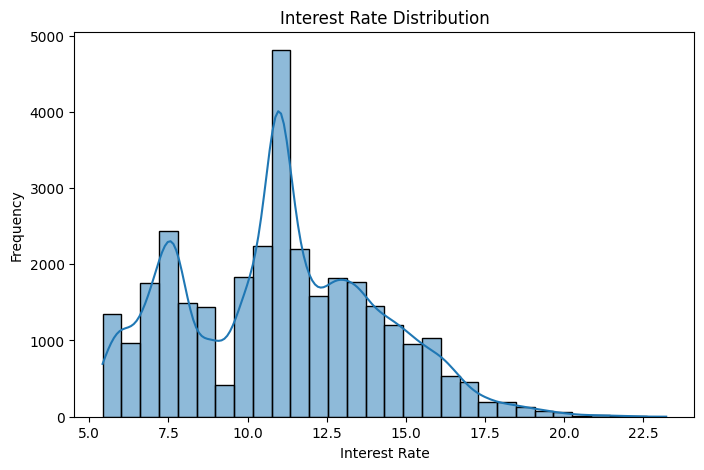

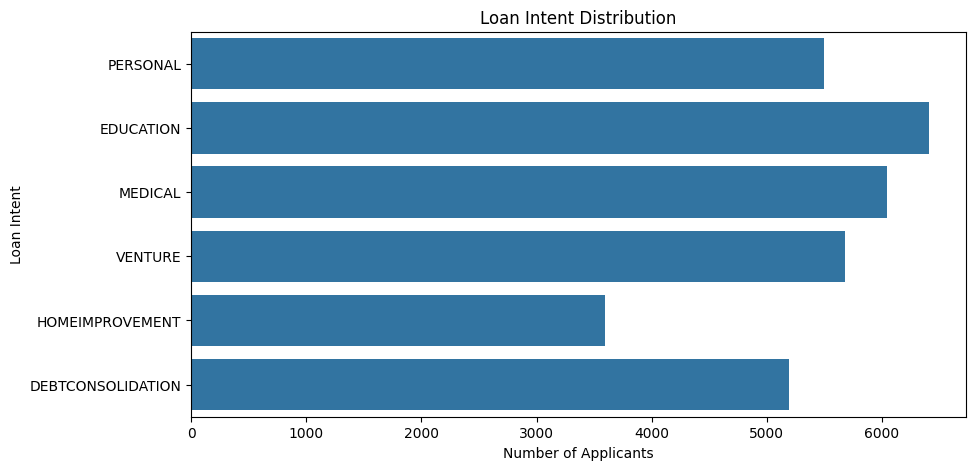

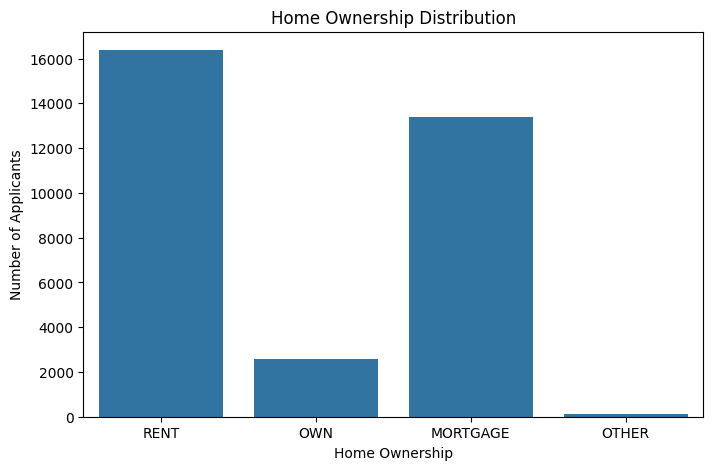

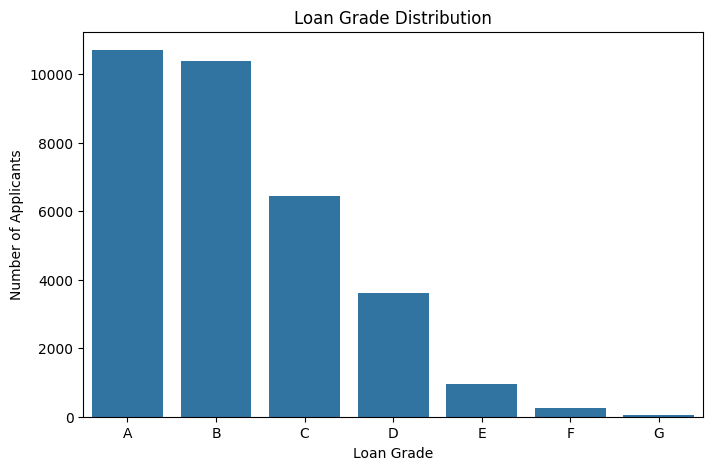


--- Inspecting Extreme/Unrealistic Age Outliers (>100) ---
       person_age  person_income  loan_amnt
81            144         250000       4800
183           144         200000       6000
575           123          80004      20400
747           123          78000      20000
32297         144        6000000       5000

--- Inspecting Extreme Employment Length Outliers (>60 years) ---
     person_age  person_emp_length
0            22              123.0
210          21              123.0

Shape after removing unrealistic domain values: (32409, 12)
Number of income outliers based on IQR boundary: 1474


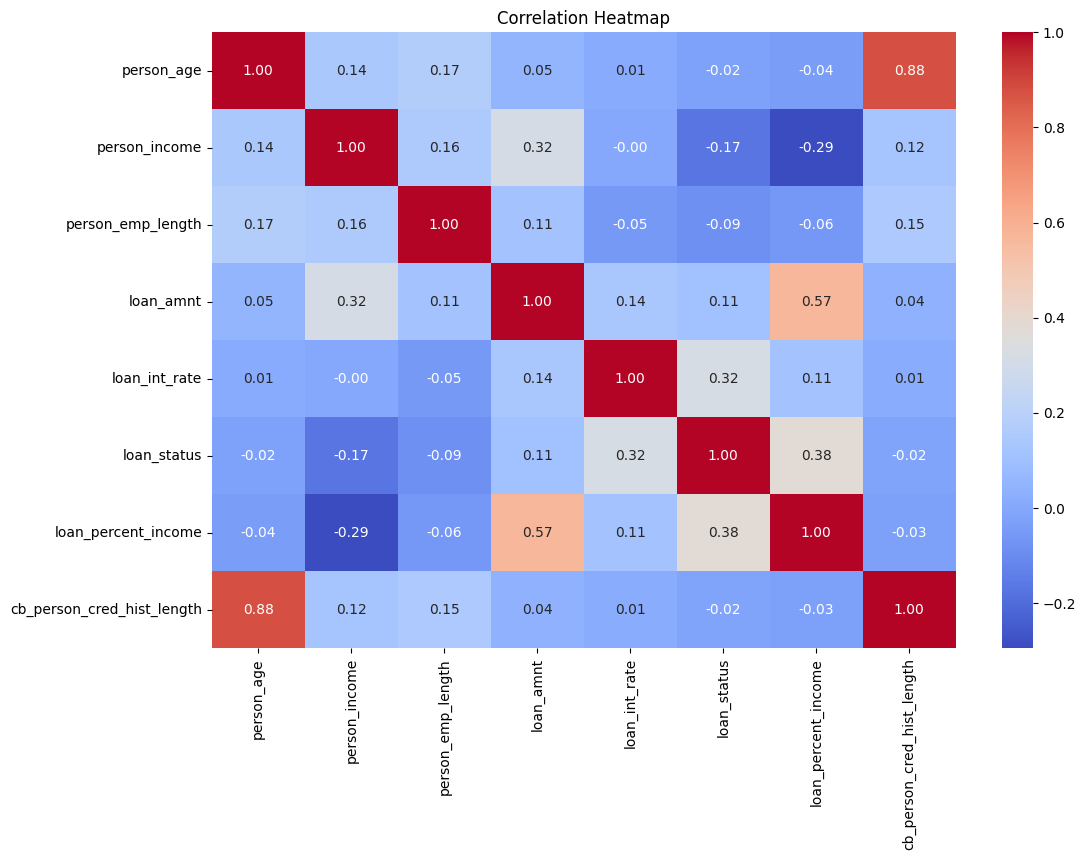

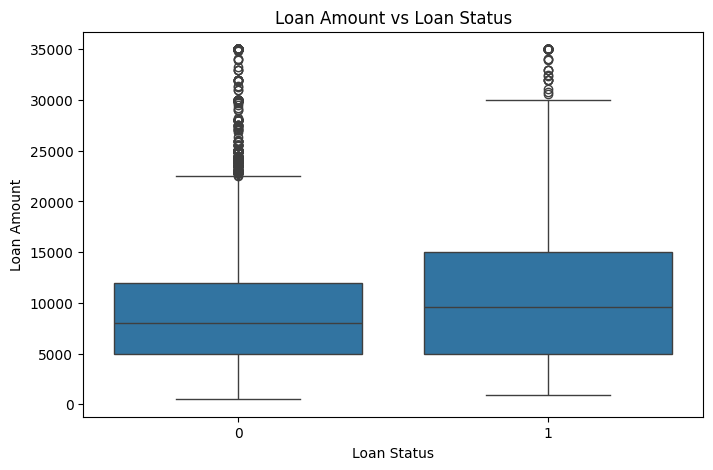

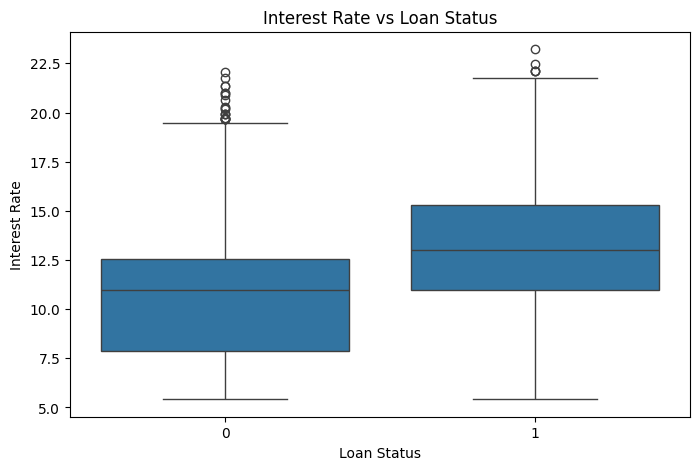

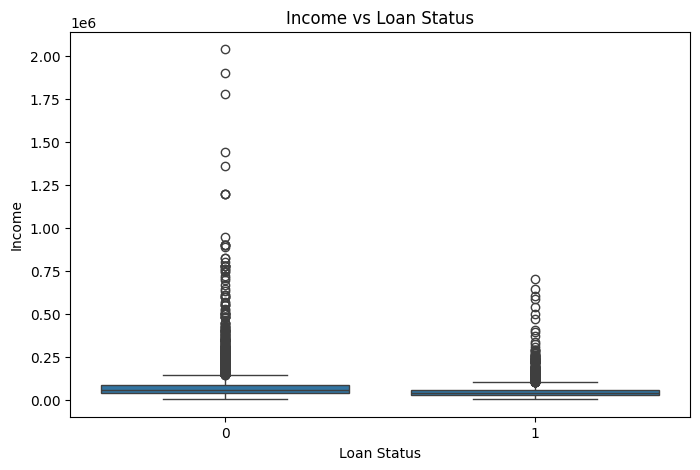


Encoding completed successfully.
New Encoded Dataset Shape: (32409, 23)

First 5 rows of encoded data:
   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
1          21           9600                5.0       1000          11.14   
2          25           9600                1.0       5500          12.87   
3          23          65500                4.0      35000          15.23   
4          24          54400                8.0      35000          14.27   
5          21           9900                2.0       2500           7.14   

   loan_status  loan_percent_income  cb_person_cred_hist_length  \
1            0                 0.10                           2   
2            1                 0.57                           3   
3            1                 0.53                           2   
4            1                 0.55                           4   
5            1                 0.25                           2   

   person_home_ownership_OTHER

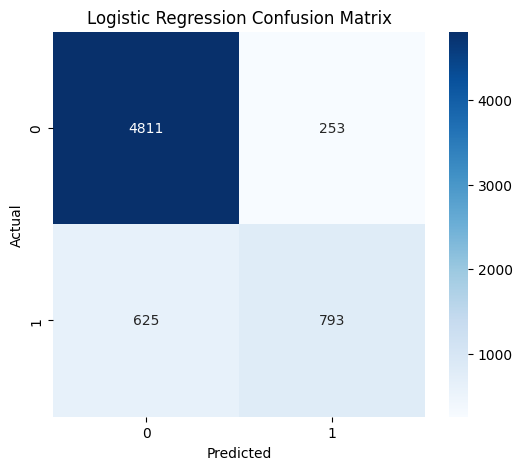


RANDOM FOREST CLASSIFIER PERFORMANCE
Accuracy : 0.9351
Precision: 0.9620
Recall   : 0.7320
F1 Score : 0.8314

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5064
           1       0.96      0.73      0.83      1418

    accuracy                           0.94      6482
   macro avg       0.95      0.86      0.90      6482
weighted avg       0.94      0.94      0.93      6482



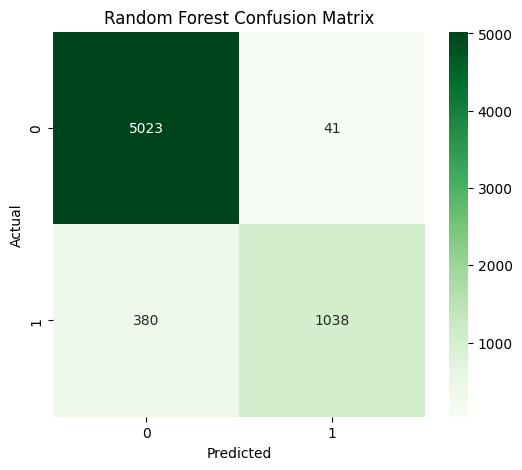


--- Model Metrics Comparison Table ---
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.864548   0.758126 0.559238  0.643669
      Random Forest  0.935051   0.962002 0.732017  0.831398


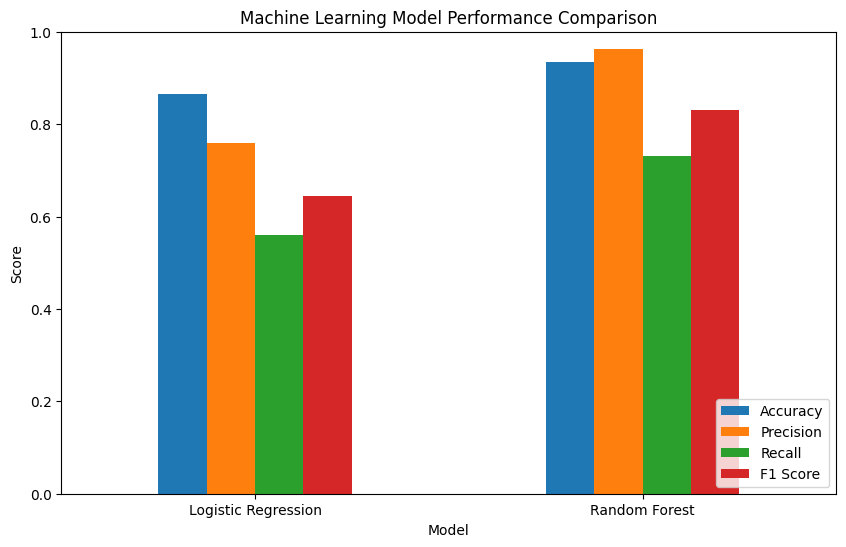

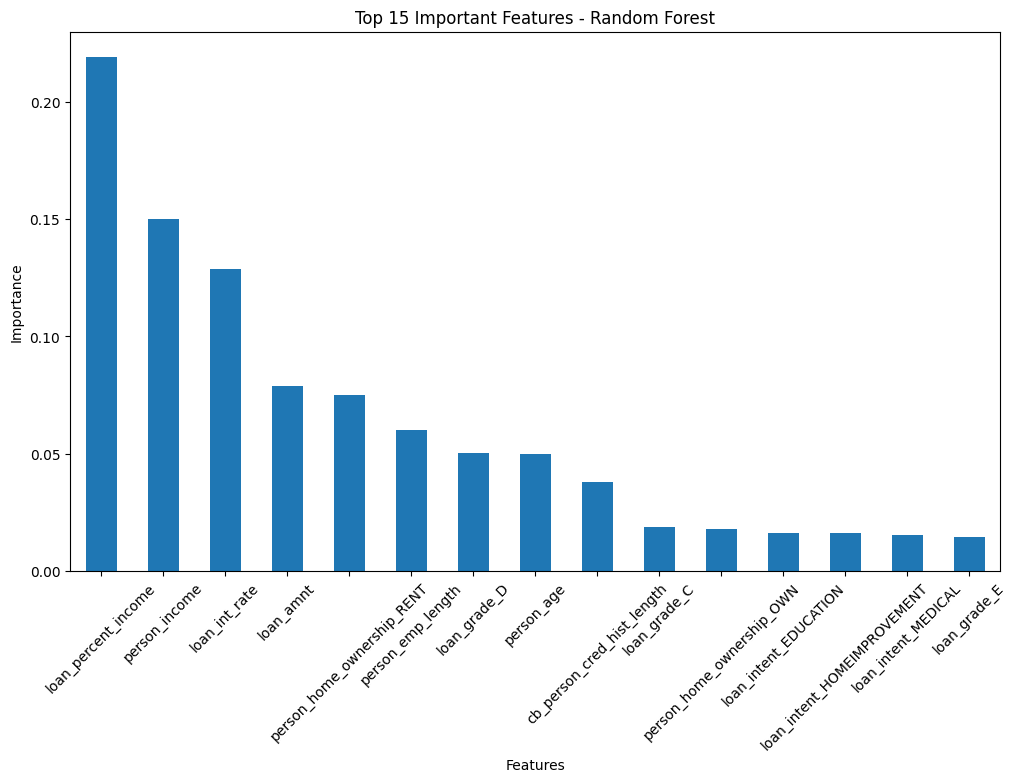


FINAL DATASET SUMMARY
Original Rows       : 32409
Original Columns    : 23
Missing Values Left : 0
Duplicate Rows Left : 0
Preprocessed dataset saved locally as 'preprocessed_credit_risk.csv'.


In [22]:
# ==============================================================================
# CREDIT RISK ANALYSIS & DATA WRANGLING
# Notebook: credit_risk_wrangling.ipynb
# ==============================================================================

# --- CELL 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!\n")

# --- CELL 2 & 3: Direct Dataset Loading ---
# Assumes credit_risk_dataset.csv is uploaded directly into Colab's files section (/content/)
df = pd.read_csv("credit_risk_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# --- CELL 4 & 5: Dataset Head & Tail ---
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Last 5 Rows ---")
print(df.tail())

# --- CELL 6, 7, 8, 9, 10: Dataset Info & Structural Summary ---
print("\n--- Dataset Information ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

print("\n--- Dataset Dimensions ---")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\n--- Column Names ---")
for column in df.columns:
    print(column)

print("\n--- Data Types ---")
print(df.dtypes)

# --- CELL 11, 12, 13: Check and Visualize Missing Values ---
missing_values = df.isnull().sum()
print("\n--- Missing Values Count ---")
print(missing_values)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

missing = missing_values[missing_values > 0]
plt.figure(figsize=(8, 5))
missing.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

# --- CELL 14, 15, 16: Handle Duplicates ---
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

print("\nMissing values status after duplicate removal:")
print(df.isnull().sum())

# --- CELL 17 & 18: Impute Missing Numerical Values with Median ---
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

print("\nMissing numerical values handled successfully.")
print("Missing values remaining:")
print(df.isnull().sum())

# --- CELL 19, 20, 21: Categorical Feature Analysis ---
categorical_columns = df.select_dtypes(include="object").columns

print("\n--- Categorical Columns ---")
for column in categorical_columns:
    print(column)

print("\n--- Unique Values per Categorical Column ---")
for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(df[column].unique())

print("\n--- Value Counts per Categorical Column ---")
for column in categorical_columns:
    print("==============================")
    print(column)
    print("==============================")
    print(df[column].value_counts())

# --- CELL 22, 23, 24: Target Distribution (loan_status) ---
print("\n--- Target Variable Distribution (0 = Non-Default, 1 = Default) ---")
print(df["loan_status"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.show()

target_percentage = df["loan_status"].value_counts(normalize=True) * 100
print("\nTarget Class Percentages:")
print(target_percentage)

# --- CELL 25, 26, 27, 28, 29: Feature Distributions & Outlier Checks ---
# Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["person_age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Income Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["person_income"], bins=50, kde=True)
plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

# Income Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["person_income"])
plt.title("Income Outlier Detection")
plt.xlabel("Annual Income")
plt.show()

# Loan Amount Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["loan_amnt"], bins=40, kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

# Interest Rate Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["loan_int_rate"], bins=30, kde=True)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.show()

# --- CELL 30, 31, 32: Categorical Feature Visualizations ---
# Loan Intent
plt.figure(figsize=(10, 5))
sns.countplot(y="loan_intent", data=df)
plt.title("Loan Intent Distribution")
plt.xlabel("Number of Applicants")
plt.ylabel("Loan Intent")
plt.show()

# Home Ownership
plt.figure(figsize=(8, 5))
sns.countplot(x="person_home_ownership", data=df)
plt.title("Home Ownership Distribution")
plt.xlabel("Home Ownership")
plt.ylabel("Number of Applicants")
plt.show()

# Loan Grade
plt.figure(figsize=(8, 5))
sns.countplot(x="loan_grade", data=df, order=sorted(df["loan_grade"].unique()))
plt.title("Loan Grade Distribution")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Applicants")
plt.show()

# --- CELL 33, 34, 35, 36: Outlier Identification and Removal ---
print("\n--- Inspecting Extreme/Unrealistic Age Outliers (>100) ---")
print(df[df["person_age"] > 100][["person_age", "person_income", "loan_amnt"]])

print("\n--- Inspecting Extreme Employment Length Outliers (>60 years) ---")
print(df[df["person_emp_length"] > 60][["person_age", "person_emp_length"]])

# Filter unrealistic records
df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 60]
print("\nShape after removing unrealistic domain values:", df.shape)

# IQR Outlier Detection on Income
Q1 = df["person_income"].quantile(0.25)
Q3 = df["person_income"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

income_outliers = df[(df["person_income"] < lower_bound) | (df["person_income"] > upper_bound)]
print("Number of income outliers based on IQR boundary:", len(income_outliers))

# --- CELL 37, 38, 39, 40: Bivariate & Correlation Analysis ---
numeric_columns = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_columns.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Loan Amount vs Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="loan_amnt", data=df)
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

# Interest Rate vs Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="loan_int_rate", data=df)
plt.title("Interest Rate vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate")
plt.show()

# Income vs Loan Status
plt.figure(figsize=(8, 5))
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title("Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Income")
plt.show()

# --- CELL 41 & 42: One-Hot Encoding Categorical Variables ---
categorical_cols_to_encode = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)
print("\nEncoding completed successfully.")
print("New Encoded Dataset Shape:", df_encoded.shape)
print("\nFirst 5 rows of encoded data:")
print(df_encoded.head())

# --- CELL 43: Feature & Target Splitting ---
X = df_encoded.drop("loan_status", axis=1)
y = df_encoded["loan_status"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

# --- CELL 44: Stratified Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nTraining set dimensions:", X_train.shape)
print("Testing set dimensions :", X_test.shape)

# --- CELL 45: Feature Scaling / Standardization ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nStandard Scaling completed.")

# --- CELL 46, 47, 48, 49: Model 1 - Logistic Regression ---
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)
logistic_predictions = logistic_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, logistic_predictions)
lr_precision = precision_score(y_test, logistic_predictions)
lr_recall = recall_score(y_test, logistic_predictions)
lr_f1 = f1_score(y_test, logistic_predictions)

print("\n==========================================")
print("LOGISTIC REGRESSION PERFORMANCE")
print("==========================================")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, logistic_predictions))

lr_cm = confusion_matrix(y_test, logistic_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- CELL 50, 51, 52, 53: Model 2 - Random Forest Classifier ---
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)
random_forest_predictions = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, random_forest_predictions)
rf_precision = precision_score(y_test, random_forest_predictions)
rf_recall = recall_score(y_test, random_forest_predictions)
rf_f1 = f1_score(y_test, random_forest_predictions)

print("\n==========================================")
print("RANDOM FOREST CLASSIFIER PERFORMANCE")
print("==========================================")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, random_forest_predictions))

rf_cm = confusion_matrix(y_test, random_forest_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- CELL 54 & 55: Model Evaluation & Performance Comparison ---
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1]
})

print("\n--- Model Metrics Comparison Table ---")
print(results.to_string(index=False))

results_plot = results.set_index("Model")
results_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

# --- CELL 56: Feature Importance Analysis (Random Forest) ---
feature_importance = pd.Series(random_forest_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feature_importance.head(15).plot(kind="bar")
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# --- CELL 57 & 58: Save Preprocessed Dataset & Final Report ---
df_encoded.to_csv("preprocessed_credit_risk.csv", index=False)

print("\n==========================================")
print("FINAL DATASET SUMMARY")
print("==========================================")
print("Original Rows       :", df_encoded.shape[0])
print("Original Columns    :", df_encoded.shape[1])
print("Missing Values Left :", df_encoded.isnull().sum().sum())
print("Duplicate Rows Left :", df_encoded.duplicated().sum())
print("Preprocessed dataset saved locally as 'preprocessed_credit_risk.csv'.")